In [1]:
%%time
import torch, subprocess

print("PyTorch version:", torch.__version__)
print("CUDA built:",      torch.backends.cuda.is_built())
print("CUDA available:",  torch.cuda.is_available())
print("Device count:",    torch.cuda.device_count())

result = subprocess.run('ls /dev/nvidia* 2>/dev/null || echo "NO NVIDIA DEVICES"',
                        shell=True, capture_output=True, text=True)
print("Devices:", result.stdout.strip())

result2 = subprocess.run('echo $SLURM_JOB_GPUS $CUDA_VISIBLE_DEVICES',
                         shell=True, capture_output=True, text=True)
print("SLURM GPUs:", result2.stdout.strip())

PyTorch version: 2.8.0+cu128
CUDA built: True
CUDA available: True
Device count: 1
Devices: /dev/nvidia-modeset
/dev/nvidia-uvm
/dev/nvidia-uvm-tools
/dev/nvidia0
/dev/nvidia1
/dev/nvidia2
/dev/nvidia3
/dev/nvidiactl

/dev/nvidia-caps:
nvidia-cap1
nvidia-cap2
SLURM GPUs: 0 0


# Sentiment & Emotion Analysis v3 — HPC Edition

Model-agnostic pipeline for tweet sentiment/emotion classification.
Runs **ten models** sequentially on both the AI-general and AI+Art test sets,
then queues full-dataset runs.

**v3 changes (May 2026):**
- Adds AI+Art subset (`AItrust_Art_pruned_twit_dict_test.json`) as a parallel test target
- Runs sentiment (3-class), emotion-single (4-class, 7-class, 15-class), and emotion-multilabel (11-class, 28-class)
- Comparative visualization across AI-general vs AI+Art subsets
- Uses canonical file names from Sanity Check notebook / notebook_setup.md
- CardiffNLP preprocessing on RAW tweet text (model's own preprocessing, not `clean_tweet_text`)
- Adds supervisor's v2 models + cross-model comparison dashboard

**Models (10 total):**
1. `cardiffnlp/twitter-roberta-base-sentiment-latest` — sentiment, 3-class
2. `cardiffnlp/twitter-xlm-roberta-base-sentiment` — sentiment, 3-class, multilingual
3. `cardiffnlp/twitter-roberta-base-emotion` — emotion, 4-class single-label
4. `cardiffnlp/twitter-roberta-base-emotion-latest` — emotion, 11-class multilabel (SuperTweetEval)
5. `cardiffnlp/twitter-roberta-base-emotion-multilabel-latest` — emotion, 11-class multilabel (SemEval 2018)
6. `finiteautomata/bertweet-base-sentiment-analysis` — sentiment, 3-class (BERTweet)
7. `finiteautomata/bertweet-base-emotion-analysis` — emotion, 7-class single-label (BERTweet)
8. `wesleyacheng/twitter-emotion-classification-with-bert` — emotion, 3-class single-label
9. `Supreeth/DeBERTa-Twitter-Emotion-Classification` — emotion, 15-class single-label
10. `bhadresh-savani/bert-base-go-emotion` — emotion, 28-class multilabel (GoEmotions)

**Runtime estimates (test sets only, CPU):** ~10-15 min total (10 models × 2 datasets).
**Full dataset:** Queue for GPU session (see Section 8).

# 0. Environment & Paths

In [2]:
%%time
import os
from pathlib import Path
import sys

BASE_PATH = Path("/projects/ComputationalPhilosophyLab/TwitterDataAnalysis")

twits_folder        = BASE_PATH / "Raw Data" / "Twits"
test_folder         = BASE_PATH / "Raw Data"
datasets_folder     = BASE_PATH / "Data Sets"
cleanedds_folder    = BASE_PATH / "Data Sets" / "Cleaned Data"
networks_folder     = BASE_PATH / "Data Sets" / "Networks"
literature_folder   = BASE_PATH / "Literature"
topic_models_folder = BASE_PATH / "Models" / "Topic Modeling"
sentiment_folder    = BASE_PATH / "Models" / "Sentiment"
sentiment_folder.mkdir(parents=True, exist_ok=True)
block_folder        = cleanedds_folder / "Blocks"

PLOT_DIR = sentiment_folder / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_PATH:", BASE_PATH)
print("cleanedds_folder exists:", cleanedds_folder.exists())
print("sentiment_folder:", sentiment_folder)

BASE_PATH: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis
cleanedds_folder exists: True
sentiment_folder: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Sentiment


In [3]:
%%time
import os
for name in ['AItrust_twits_pruned_dict.json', 'AItrust_pruned_twits.json',
             'AItrust_Art_pruned_twit_dict.json', 'AItrust_Art_pruned_twit_dict_test.json',
             'AItrust_twits_pruned_dict_test.json']:
    p = cleanedds_folder / name
    print(f"{'YES' if p.exists() else 'NO ':3s}  {p.stat().st_size/1e6:.1f}MB  {name}" if p.exists() else f"NO   ---      {name}")

YES  36322.8MB  AItrust_twits_pruned_dict.json
YES  3846.9MB  AItrust_pruned_twits.json
YES  7309.6MB  AItrust_Art_pruned_twit_dict.json
YES  0.4MB  AItrust_Art_pruned_twit_dict_test.json
YES  1.9MB  AItrust_twits_pruned_dict_test.json


# 1. Model Registry & Configuration

In [4]:
%%time
import json, os, re, time, random
from datetime import datetime
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
%%time
MODEL_REGISTRY = {
    # ── Sentiment models ─────────────────────────────────────────
    'cardiffnlp/twitter-roberta-base-sentiment-latest': {
        'task': 'sentiment',
        'classification': 'single',
        'preprocessing': 'cardiffnlp',
        'labels': {0: 'negative', 1: 'neutral', 2: 'positive'},
    },
    'cardiffnlp/twitter-xlm-roberta-base-sentiment': {
        'task': 'sentiment',
        'classification': 'single',
        'preprocessing': 'cardiffnlp',
        'labels': {0: 'Negative', 1: 'Neutral', 2: 'Positive'},
    },
    'finiteautomata/bertweet-base-sentiment-analysis': {
        'task': 'sentiment',
        'classification': 'single',
        'preprocessing': 'cardiffnlp',
        'labels': {0: 'NEG', 1: 'NEU', 2: 'POS'},
    },
    # ── Emotion models (single-label) ────────────────────────────
    'cardiffnlp/twitter-roberta-base-emotion': {
        'task': 'emotion',
        'classification': 'single',
        'preprocessing': 'cardiffnlp',
        'labels': {0: 'anger', 1: 'joy', 2: 'optimism', 3: 'sadness'},
    },
    'finiteautomata/bertweet-base-emotion-analysis': {
        'task': 'emotion',
        'classification': 'single',
        'preprocessing': 'cardiffnlp',
        'labels': {0: 'others', 1: 'joy', 2: 'sadness', 3: 'anger',
                   4: 'surprise', 5: 'disgust', 6: 'fear'},
    },
    'wesleyacheng/twitter-emotion-classification-with-bert': {
        'task': 'emotion',
        'classification': 'single',
        'preprocessing': 'none',
        'labels': {0: 'ANGER', 1: 'JOY', 2: 'SADNESS'},
    },
    'Supreeth/DeBERTa-Twitter-Emotion-Classification': {
        'task': 'emotion',
        'classification': 'single',
        'preprocessing': 'none',
        'labels': {
             0: 'anger',    1: 'boredom',  2: 'empty',   3: 'enthusiasm',
             4: 'fear',     5: 'fun',      6: 'happiness', 7: 'hate',
             8: 'joy',      9: 'love',    10: 'neutral',  11: 'relief',
            12: 'sadness', 13: 'surprise', 14: 'worry',
        },
    },
    # ── Emotion models (multilabel) ──────────────────────────────
    'cardiffnlp/twitter-roberta-base-emotion-latest': {
        'task': 'emotion',
        'classification': 'multilabel',
        'preprocessing': 'cardiffnlp',
        'labels': {
            0: 'anger', 1: 'anticipation', 2: 'disgust', 3: 'fear',
            4: 'joy', 5: 'love', 6: 'optimism', 7: 'pessimism',
            8: 'sadness', 9: 'surprise', 10: 'trust',
        },
    },
    'cardiffnlp/twitter-roberta-base-emotion-multilabel-latest': {
        'task': 'emotion',
        'classification': 'multilabel',
        'preprocessing': 'cardiffnlp',
        'labels': {
            0: 'anger', 1: 'anticipation', 2: 'disgust', 3: 'fear',
            4: 'joy', 5: 'love', 6: 'optimism', 7: 'pessimism',
            8: 'sadness', 9: 'surprise', 10: 'trust',
        },
    },
    'bhadresh-savani/bert-base-go-emotion': {
        'task': 'emotion',
        'classification': 'multilabel',
        'preprocessing': 'none',
        'labels': {
             0: 'admiration',    1: 'amusement',     2: 'anger',       3: 'annoyance',
             4: 'approval',      5: 'caring',         6: 'confusion',   7: 'curiosity',
             8: 'desire',        9: 'disappointment', 10: 'disapproval', 11: 'disgust',
            12: 'embarrassment', 13: 'excitement',    14: 'fear',       15: 'gratitude',
            16: 'grief',         17: 'joy',           18: 'love',       19: 'nervousness',
            20: 'optimism',      21: 'pride',         22: 'realization', 23: 'relief',
            24: 'remorse',       25: 'sadness',       26: 'surprise',   27: 'neutral',
        },
    },
}

# ── Which models to run this session ─────────────────────────────
# Comment out any you want to skip.
MODELS_TO_RUN = [
    'cardiffnlp/twitter-roberta-base-sentiment-latest',
    'cardiffnlp/twitter-xlm-roberta-base-sentiment',
    'cardiffnlp/twitter-roberta-base-emotion-latest',
    'cardiffnlp/twitter-roberta-base-emotion-multilabel-latest',
    'cardiffnlp/twitter-roberta-base-emotion',
    'finiteautomata/bertweet-base-sentiment-analysis',
    'finiteautomata/bertweet-base-emotion-analysis',
    'wesleyacheng/twitter-emotion-classification-with-bert',
    'Supreeth/DeBERTa-Twitter-Emotion-Classification',
    'bhadresh-savani/bert-base-go-emotion',
]

MULTILABEL_THRESHOLD = 0.5
BATCH_SIZE           = 512


# ── Input datasets ───────────────────────────────────────────────
DATASETS = {
    'ai_test': {
        'path': cleanedds_folder / 'AItrust_twits_pruned_dict_test.json',
        'label': 'AI General (Test)',
    },
    'art_test': {
        'path': cleanedds_folder / 'AItrust_Art_pruned_twit_dict_test.json',
        'label': 'AI+Art (Test)',
    },
    'ai_full': {
        'path': cleanedds_folder / 'AItrust_twits_pruned_dict.json',
        'label': 'AI General (Full)',
    },
    'art_full': {
        'path': cleanedds_folder / 'AItrust_Art_pruned_twit_dict.json',
        'label': 'AI+Art (Full)',
    },
}

TEST_SETS = ['ai_test', 'art_test']
FULL_SETS = ['ai_full', 'art_full']

# Verify files exist
for ds_key, ds in DATASETS.items():
    exists = ds['path'].exists()
    print(f"  {ds_key}: {ds['path'].name} exists={exists}")

print(f"\nModels to run: {len(MODELS_TO_RUN)}")
for m in MODELS_TO_RUN:
    cfg = MODEL_REGISTRY[m]
    print(f"  {m.split('/')[-1]}: {cfg['task']} ({cfg['classification']}, {len(cfg['labels'])} labels)")

  ai_test: AItrust_twits_pruned_dict_test.json exists=True
  art_test: AItrust_Art_pruned_twit_dict_test.json exists=True
  ai_full: AItrust_twits_pruned_dict.json exists=True
  art_full: AItrust_Art_pruned_twit_dict.json exists=True

Models to run: 10
  twitter-roberta-base-sentiment-latest: sentiment (single, 3 labels)
  twitter-xlm-roberta-base-sentiment: sentiment (single, 3 labels)
  twitter-roberta-base-emotion-latest: emotion (multilabel, 11 labels)
  twitter-roberta-base-emotion-multilabel-latest: emotion (multilabel, 11 labels)
  twitter-roberta-base-emotion: emotion (single, 4 labels)
  bertweet-base-sentiment-analysis: sentiment (single, 3 labels)
  bertweet-base-emotion-analysis: emotion (single, 7 labels)
  twitter-emotion-classification-with-bert: emotion (single, 3 labels)
  DeBERTa-Twitter-Emotion-Classification: emotion (single, 15 labels)
  bert-base-go-emotion: emotion (multilabel, 28 labels)


# 2. Preprocessing & Inference Core

**Critical design decision:** Sentiment models run on the **raw tweet text** with
only model-specific token replacements (@mention→@user, URL→http). This is NOT
the same as `clean_tweet_text()` used for topic modeling. The CardiffNLP models
were pretrained on tweets with these specific tokens present — removing them
entirely would put the input out of distribution and degrade classification accuracy.

In [6]:
%%time
def preprocess(text, style='cardiffnlp'):
    '''Model-specific preprocessing. NOT clean_tweet_text().'''
    if style == 'cardiffnlp':
        tokens = []
        for t in text.split():
            t = '@user' if t.startswith('@') and len(t) > 1 else t
            t = 'http'  if t.startswith('http')               else t
            tokens.append(t)
        return ' '.join(tokens)
    return text


def run_batch(texts, model, tokenizer, model_config, device, threshold):
    encoded = tokenizer(
        texts, padding=True, truncation=True, max_length=128, return_tensors='pt'
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    is_deberta = 'deberta' in type(model).__module__.lower()
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=not is_deberta):
            logits = model(**encoded).logits

    results = []
    if model_config['classification'] == 'single':
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        for prob in probs:
            scores = {model_config['labels'][j]: float(prob[j]) for j in range(len(prob))}
            best   = model_config['labels'][int(prob.argmax())]
            results.append({'label': best, 'scores': scores})
    else:
        probs = torch.sigmoid(logits).cpu().numpy()
        for prob in probs:
            scores  = {model_config['labels'][j]: float(prob[j]) for j in range(len(prob))}
            actives = [model_config['labels'][j] for j in range(len(prob)) if prob[j] > threshold]
            results.append({'labels': actives, 'scores': scores})
    return results


def empty_result(model_config):
    scores = {lbl: 0.0 for lbl in model_config['labels'].values()}
    if model_config['classification'] == 'single':
        return {'label': list(model_config['labels'].values())[0], 'scores': scores}
    return {'labels': [], 'scores': scores}


def classify_file(input_path, output_path, model_name, model_config,
                  hf_model, hf_tokenizer, device, batch_size=512, threshold=0.5):
    '''Classify all tweets in a JSONL file. Writes output JSONL with classifications.'''
    with open(input_path, 'r', encoding='utf-8') as f:
        total = sum(1 for _ in f)
    print(f"  Input: {input_path.name} ({total:,} tweets)")

    buffer, meta = [], []
    with open(input_path, 'r', encoding='utf-8') as infile, \
         open(output_path, 'w', encoding='utf-8') as outfile:

        for line in tqdm(infile, total=total, desc=f"  {model_name.split('/')[-1]}"):
            twit = json.loads(line)
            if 'classifications' not in twit:
                twit['classifications'] = {}

            cleaned = preprocess(twit.get('text', ''), style=model_config['preprocessing'])

            if cleaned.strip():
                buffer.append(cleaned)
                meta.append(twit)
            else:
                twit['classifications'][model_name] = empty_result(model_config)
                outfile.write(json.dumps(twit, ensure_ascii=False) + '\n')

            if len(buffer) >= batch_size:
                for twit_i, result in zip(meta, run_batch(buffer, hf_model, hf_tokenizer,
                                                          model_config, device, threshold)):
                    twit_i['classifications'][model_name] = result
                    outfile.write(json.dumps(twit_i, ensure_ascii=False) + '\n')
                buffer.clear()
                meta.clear()

        if buffer:
            for twit_i, result in zip(meta, run_batch(buffer, hf_model, hf_tokenizer,
                                                      model_config, device, threshold)):
                twit_i['classifications'][model_name] = result
                outfile.write(json.dumps(twit_i, ensure_ascii=False) + '\n')

    print(f"  Saved → {output_path.name}")
    return total

print("Core functions defined.")

Core functions defined.


# 3. Sanity Check Helper

In [7]:
%%time
def sanity_check(output_path, model_name, model_config, num_samples=5):
    cls_type = model_config['classification']
    print(f'\nSanity check: {output_path.name}')
    with open(output_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            twit   = json.loads(line)
            result = twit.get('classifications', {}).get(model_name)
            if result is None:
                print(f'  [Line {i+1}] MISSING')
                continue
            scores = result.get('scores', {})
            if cls_type == 'single':
                label = result.get('label', '?')
                top_score = max(scores.values()) if scores else 0
                print(f'  [Line {i+1}] {label} ({top_score:.3f}) | {twit.get("text", "")[:80]}')
            else:
                labels = result.get('labels', [])
                top3 = dict(sorted(scores.items(), key=lambda x: -x[1])[:3])
                print(f'  [Line {i+1}] {labels} | top-3: {top3}')
            if i + 1 >= num_samples:
                break
    print('  Done.\n')

# 4. Run All Models on All Test Sets

This is the main execution cell. For each model × dataset combination:
1. Load model (cached after first load)
2. Classify all tweets
3. Run sanity check
4. Store output path for visualization

**Estimated runtime:** ~10-15 min total on CPU for the test sets (~200-900 tweets each).

In [8]:
%%time
# Clear GPU memory from previous models
#torch.cuda.empty_cache()
#loaded_models.clear()

In [9]:
%%time
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Cache loaded models to avoid re-downloading
loaded_models = {}
run_results = {}  # (model_name, ds_key) → output_path

t0_all = time.time()

for model_name in MODELS_TO_RUN:
    model_config = MODEL_REGISTRY[model_name]
    model_alias  = model_name.split('/')[-1]

    # Load model (once per model)
    if model_name not in loaded_models:
        print(f"\nLoading {model_alias}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        hf_model  = AutoModelForSequenceClassification.from_pretrained(model_name)
        hf_model.to(device).eval()
        loaded_models[model_name] = (hf_model, tokenizer)
        print(f"  Loaded.")
    else:
        hf_model, tokenizer = loaded_models[model_name]

    # Run on each test dataset
    for ds_key in TEST_SETS:
        ds_info = DATASETS[ds_key]
        if not ds_info['path'].exists():
            print(f"  SKIP {ds_key}: file not found")
            continue

        output_path = cleanedds_folder / f'{ds_key}_classified_{model_alias}.json'

        t0 = time.time()
        n = classify_file(
            ds_info['path'], output_path, model_name, model_config,
            hf_model, tokenizer, device, BATCH_SIZE, MULTILABEL_THRESHOLD
        )
        elapsed = time.time() - t0
        print(f"  {n:,} tweets in {elapsed:.1f}s ({n/max(elapsed,0.01):.0f} tweets/sec)")

        sanity_check(output_path, model_name, model_config, num_samples=3)
        run_results[(model_name, ds_key)] = output_path

print(f"\n{'='*60}")
print(f"All runs complete: {len(run_results)} model×dataset combinations")
print(f"Total time: {(time.time()-t0_all)/60:.1f} min")

Device: cuda
GPU: Tesla T4

Loading twitter-roberta-base-sentiment-latest...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 26659.55it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loaded.
  Input: AItrust_twits_pruned_dict_test.json (881 tweets)


  twitter-roberta-base-sentiment-latest:   0%|          | 0/881 [00:00<?, ?it/s]/tmp/ipykernel_1341470/753667056.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=not is_deberta):
  twitter-roberta-base-sentiment-latest: 100%|██████████| 881/881 [00:01<00:00, 692.03it/s]


  Saved → ai_test_classified_twitter-roberta-base-sentiment-latest.json
  881 tweets in 1.7s (508 tweets/sec)

Sanity check: ai_test_classified_twitter-roberta-base-sentiment-latest.json
  [Line 1] neutral (0.708) | RT @WonderBotz: GENIE automatically captures all user activity and utilizes one-
  [Line 2] positive (0.607) | GENIE automatically captures all user activity and utilizes one-of-a-kind AI to 
  [Line 3] neutral (0.508) | We really looked at this man and collectively agreed that he is a soft-dom acros
  Done.

  Input: AItrust_Art_pruned_twit_dict_test.json (216 tweets)


...

  Loaded.
  Input: AItrust_twits_pruned_dict_test.json (881 tweets)


  bert-base-go-emotion: 100%|██████████| 881/881 [00:00<00:00, 966.03it/s]


  Saved → ai_test_classified_bert-base-go-emotion.json
  881 tweets in 1.5s (600 tweets/sec)

Sanity check: ai_test_classified_bert-base-go-emotion.json
  [Line 1] [] | top-3: {'neutral': 0.380615234375, 'surprise': 0.3740234375, 'admiration': 0.06878662109375}
  [Line 2] ['neutral'] | top-3: {'neutral': 0.7275390625, 'approval': 0.06427001953125, 'disapproval': 0.0360107421875}
  [Line 3] ['neutral'] | top-3: {'neutral': 0.625, 'approval': 0.089599609375, 'disapproval': 0.055938720703125}
  Done.

  Input: AItrust_Art_pruned_twit_dict_test.json (216 tweets)


  bert-base-go-emotion: 100%|██████████| 216/216 [00:00<00:00, 40256.37it/s]


  Saved → art_test_classified_bert-base-go-emotion.json
  216 tweets in 0.3s (628 tweets/sec)

Sanity check: art_test_classified_bert-base-go-emotion.json
  [Line 1] [] | top-3: {'curiosity': 0.33203125, 'neutral': 0.303955078125, 'confusion': 0.2086181640625}
  [Line 2] ['neutral'] | top-3: {'neutral': 0.69189453125, 'curiosity': 0.16650390625, 'confusion': 0.085693359375}
  [Line 3] [] | top-3: {'neutral': 0.461669921875, 'amusement': 0.26416015625, 'annoyance': 0.09503173828125}
  Done.


All runs complete: 20 model×dataset combinations
Total time: 0.8 min


In [10]:
%%time
# ── Count ALL results ────────────────────────────────────────────
from collections import Counter

for ds_label, ds_prefix in [('AI+Art', 'art_test'), ('AI General', 'ai_test')]:
    print(f"\n{'='*60}")
    print(f"  {ds_label}")
    print(f"{'='*60}")
    for model_name in MODELS_TO_RUN:
        model_alias = model_name.split('/')[-1]
        model_config = MODEL_REGISTRY[model_name]
        cls_type = model_config['classification']
        path = cleanedds_folder / f'{ds_prefix}_classified_{model_alias}.json'
        
        if not path.exists():
            print(f"\n  {model_alias}: NOT FOUND")
            continue
        
        counts = Counter()
        total = 0
        with open(path, 'r') as f:
            for line in f:
                tw = json.loads(line)
                total += 1
                r = tw.get('classifications', {}).get(model_name, {})
                if cls_type == 'single':
                    counts[r.get('label', 'unknown')] += 1
                else:
                    for lbl in r.get('labels', []):
                        counts[lbl] += 1
        
        print(f"\n  {model_alias} (n={total}):")
        for label in sorted(counts.keys()):
            pct = counts[label] / total * 100
            print(f"    {label:15s}: {counts[label]:4d}  ({pct:5.1f}%)")


  AI+Art

  twitter-roberta-base-sentiment-latest (n=216):
    negative       :   85  ( 39.4%)
    neutral        :   94  ( 43.5%)
    positive       :   37  ( 17.1%)

  twitter-xlm-roberta-base-sentiment (n=216):
    Negative       :   95  ( 44.0%)
    Neutral        :   92  ( 42.6%)
    Positive       :   29  ( 13.4%)

  twitter-roberta-base-emotion-latest (n=216):
    anger          :   37  ( 17.1%)
    anticipation   :  133  ( 61.6%)
    disgust        :   73  ( 33.8%)
    fear           :    3  (  1.4%)
    joy            :   79  ( 36.6%)
    love           :    5  (  2.3%)
    optimism       :   58  ( 26.9%)
    pessimism      :    2  (  0.9%)
    sadness        :    9  (  4.2%)
    surprise       :    3  (  1.4%)

  twitter-roberta-base-emotion-multilabel-latest (n=216):
    anger          :   49  ( 22.7%)
    anticipation   :  131  ( 60.6%)
    disgust        :   53  ( 24.5%)
    fear           :    1  (  0.5%)
    joy            :   72  ( 33.3%)
    love           :    5  (  

# 5. Human Validation Samples

Generates stratified CSVs for human validation — one per model × dataset.
Open the CSV, read the `text` column, fill in `human_label`, then run the
agreement cell (Section 6).

In [11]:
%%time
SAMPLE_PER_CLASS = 30  # per-class sample for small test sets

for (model_name, ds_key), output_path in run_results.items():
    model_config = MODEL_REGISTRY[model_name]
    model_alias  = model_name.split('/')[-1]
    cls_type     = model_config['classification']

    by_class = defaultdict(list)
    with open(output_path, 'r', encoding='utf-8') as f:
        for line in f:
            tw = json.loads(line)
            result = tw.get('classifications', {}).get(model_name, {})
            if cls_type == 'single':
                label = result.get('label', 'unknown')
            else:
                label = ','.join(sorted(result.get('labels', ['none']))) or 'none'
            by_class[label].append({
                'tweet_id': tw.get('id', ''),
                'author_id': tw.get('author_id', ''),
                'text': tw.get('text', ''),
                'predicted_label': label,
                'confidence': max(result.get('scores', {}).values()) if result.get('scores') else 0,
                'human_label': '',
            })

    rows = []
    for label, tweets in by_class.items():
        random.seed(42)
        sampled = random.sample(tweets, min(SAMPLE_PER_CLASS, len(tweets)))
        rows.extend(sampled)

    random.shuffle(rows)
    df_val = pd.DataFrame(rows)
    val_path = sentiment_folder / f'validation_{ds_key}_{model_alias}.csv'
    df_val.to_csv(val_path, index=False)
    print(f"  {ds_key} × {model_alias}: {len(df_val)} tweets → {val_path.name}")

print("\nOpen CSVs and fill 'human_label' column, then run Section 6.")

  ai_test × twitter-roberta-base-sentiment-latest: 90 tweets → validation_ai_test_twitter-roberta-base-sentiment-latest.csv
  art_test × twitter-roberta-base-sentiment-latest: 90 tweets → validation_art_test_twitter-roberta-base-sentiment-latest.csv
  ai_test × twitter-xlm-roberta-base-sentiment: 90 tweets → validation_ai_test_twitter-xlm-roberta-base-sentiment.csv
  art_test × twitter-xlm-roberta-base-sentiment: 89 tweets → validation_art_test_twitter-xlm-roberta-base-sentiment.csv
  ai_test × twitter-roberta-base-emotion-latest: 407 tweets → validation_ai_test_twitter-roberta-base-emotion-latest.csv
  art_test × twitter-roberta-base-emotion-latest: 214 tweets → validation_art_test_twitter-roberta-base-emotion-latest.csv
  ai_test × twitter-roberta-base-emotion-multilabel-latest: 337 tweets → validation_ai_test_twitter-roberta-base-emotion-multilabel-latest.csv
  art_test × twitter-roberta-base-emotion-multilabel-latest: 163 tweets → validation_art_test_twitter-roberta-base-emotion-mu

# 6. Compute Agreement (after labeling)

In [12]:
%%time
# Run AFTER you've labeled the validation CSVs
from sklearn.metrics import classification_report, cohen_kappa_score

for (model_name, ds_key), output_path in run_results.items():
    model_alias = model_name.split('/')[-1]
    val_path = sentiment_folder / f'validation_{ds_key}_{model_alias}.csv'

    if not val_path.exists():
        continue

    df_val = pd.read_csv(val_path)
    labeled = df_val[df_val['human_label'].notna() & (df_val['human_label'] != '')]

    if len(labeled) == 0:
        continue

    agree = (labeled['predicted_label'] == labeled['human_label']).sum()
    total = len(labeled)
    accuracy = agree / total
    kappa = cohen_kappa_score(labeled['human_label'], labeled['predicted_label'])

    print(f"\n{'='*60}")
    print(f"{ds_key} × {model_alias}")
    print(f"  Labeled: {total}, Accuracy: {accuracy:.1%}, Kappa: {kappa:.3f}")
    print(classification_report(labeled['human_label'], labeled['predicted_label'], zero_division=0))

    if accuracy >= 0.80:
        print("  → PASS: Agreement ≥ 80%. Safe to run on full dataset.")
    elif accuracy >= 0.70:
        print("  → MARGINAL: 70-80%. Consider fine-tuning or ensemble.")
    else:
        print("  → FAIL: <70%. Fine-tuning recommended.")

# 7. Visualizations (Test Data)

Minimal set of visuals for the test sets. Full-data visuals will be generated after Section 8 GPU runs.

In [13]:
%%time
## Example tweets per sentiment/emotion category

import glob

# Find all classified test files
test_files = sorted(cleanedds_folder.glob('*_test_classified_*.json'))
print(f"Found {len(test_files)} classified test files:\n")
for f in test_files:
    print(f"  {f.name}")

print("\n" + "="*70)

N_EXAMPLES = 1  # one tweet per label

for fpath in test_files:
    # Try to figure out the model name from the file
    fname = fpath.stem  # e.g. ai_test_classified_twitter-roberta-base-sentiment-latest
    
    # Read and collect by label
    by_label = defaultdict(list)
    with open(fpath, 'r', encoding='utf-8') as f:
        for line in f:
            tw = json.loads(line)
            text = tw.get('text', '')
            for model_name, result in tw.get('classifications', {}).items():
                if 'label' in result:  # single-label
                    label = result['label']
                    conf = result.get('scores', {}).get(label, 0)
                    by_label[label].append((text, conf))
                elif 'labels' in result:  # multilabel
                    for lbl in result['labels']:
                        conf = result.get('scores', {}).get(lbl, 0)
                        by_label[lbl].append((text, conf))
    
    print(f"\n{'='*70}")
    print(f"  {fname}")
    print(f"{'='*70}")
    
    for label in sorted(by_label.keys()):
        tweets = by_label[label]
        top = sorted(tweets, key=lambda x: -x[1])[:N_EXAMPLES]
        print(f"\n  {label} ({len(tweets)} tweets):")
        for text, conf in top:
            truncated = text[:140].replace('\n', ' ')
            print(f"    [{conf:.3f}] {truncated}")

Found 22 classified test files:

  AItrust_pruned_twits_test_classified_twitter-roberta-base-emotion-latest.json
  AItrust_pruned_twits_test_classified_twitter-roberta-base-sentiment-latest.json
  ai_test_classified_DeBERTa-Twitter-Emotion-Classification.json
  ai_test_classified_bert-base-go-emotion.json
  ai_test_classified_bertweet-base-emotion-analysis.json
  ai_test_classified_bertweet-base-sentiment-analysis.json
  ai_test_classified_twitter-emotion-classification-with-bert.json
  ai_test_classified_twitter-roberta-base-emotion-latest.json
  ai_test_classified_twitter-roberta-base-emotion-multilabel-latest.json
  ai_test_classified_twitter-roberta-base-emotion.json
  ai_test_classified_twitter-roberta-base-sentiment-latest.json
  ai_test_classified_twitter-xlm-roberta-base-sentiment.json
  art_test_classified_DeBERTa-Twitter-Emotion-Classification.json
  art_test_classified_bert-base-go-emotion.json
  art_test_classified_bertweet-base-emotion-analysis.json
  art_test_classified_b

## 7a. Load all classified results

In [14]:
%%time
import seaborn as sns
from collections import Counter, defaultdict

def load_results(output_path, model_name, model_config):
    """Load all classifications from a JSONL file."""
    cls_type = model_config['classification']
    all_labels = list(model_config['labels'].values())
    counts = Counter()
    tweet_results = []
    
    with open(output_path, 'r', encoding='utf-8') as f:
        for line in f:
            tw = json.loads(line)
            r = tw.get('classifications', {}).get(model_name, {})
            if cls_type == 'single':
                label = r.get('label', 'unknown')
                counts[label] += 1
                tweet_results.append({
                    'text': tw.get('text', ''),
                    'label': label,
                    'confidence': r.get('scores', {}).get(label, 0),
                    'scores': r.get('scores', {}),
                })
            else:
                actives = r.get('labels', [])
                for lbl in actives:
                    counts[lbl] += 1
                tweet_results.append({
                    'text': tw.get('text', ''),
                    'labels': actives,
                    'scores': r.get('scores', {}),
                })
    return counts, tweet_results, all_labels

# Build results dict
all_results = {}
for (model_name, ds_key), path in run_results.items():
    if not path.exists():
        continue
    config = MODEL_REGISTRY[model_name]
    alias = model_name.split('/')[-1]
    counts, tweets, labels = load_results(path, model_name, config)
    all_results[(alias, ds_key)] = {
        'counts': counts, 'tweets': tweets, 'labels': labels,
        'total': len(tweets), 'config': config, 'model_name': model_name,
    }

print(f"Loaded {len(all_results)} result sets")
for key, val in all_results.items():
    print(f"  {key[1]:10} × {key[0]:45} n={val['total']}")

Loaded 20 result sets
  ai_test    × twitter-roberta-base-sentiment-latest         n=881
  art_test   × twitter-roberta-base-sentiment-latest         n=216
  ai_test    × twitter-xlm-roberta-base-sentiment            n=881
  art_test   × twitter-xlm-roberta-base-sentiment            n=216
  ai_test    × twitter-roberta-base-emotion-latest           n=881
  art_test   × twitter-roberta-base-emotion-latest           n=216
  ai_test    × twitter-roberta-base-emotion-multilabel-latest n=881
  art_test   × twitter-roberta-base-emotion-multilabel-latest n=216
  ai_test    × twitter-roberta-base-emotion                  n=881
  art_test   × twitter-roberta-base-emotion                  n=216
  ai_test    × bertweet-base-sentiment-analysis              n=881
  art_test   × bertweet-base-sentiment-analysis              n=216
  ai_test    × bertweet-base-emotion-analysis                n=881
  art_test   × bertweet-base-emotion-analysis                n=216
  ai_test    × twitter-emotion-classif

## 7b. Sentiment distribution — AI General vs AI+Art

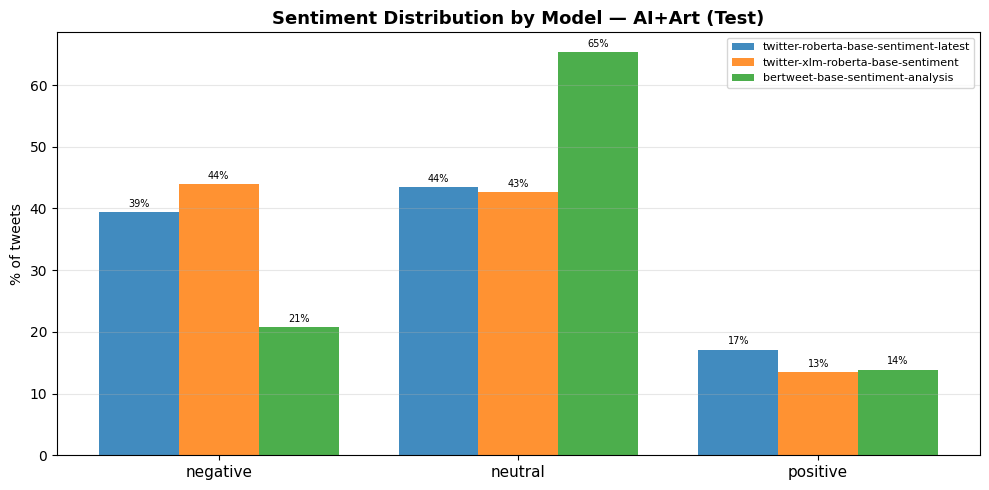

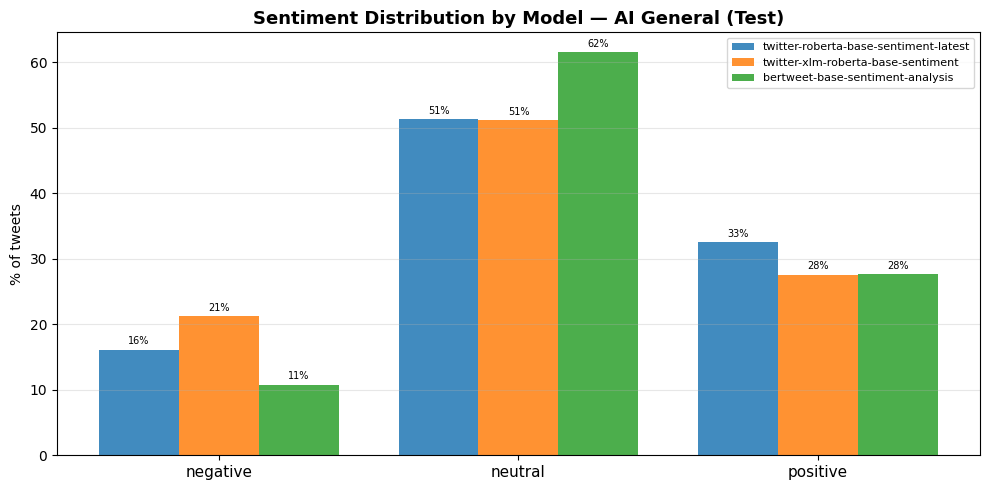

In [15]:
%%time
# ── Compare all sentiment models side by side ────────────────────
SENTIMENT_MODELS = [m for m in MODELS_TO_RUN if MODEL_REGISTRY[m]['task'] == 'sentiment']

# Normalize label names across models for comparison
SENTIMENT_NORMALIZE = {
    'negative': 'negative', 'Negative': 'negative', 'NEG': 'negative',
    'neutral': 'neutral', 'Neutral': 'neutral', 'NEU': 'neutral',
    'positive': 'positive', 'Positive': 'positive', 'POS': 'positive',
}
SENTIMENT_ORDER = ['negative', 'neutral', 'positive']
SENTIMENT_COLORS = {'negative': '#E24B4A', 'neutral': '#888780', 'positive': '#1D9E75'}

for ds_key in ['art_test', 'ai_test']:
    ds_label = DATASETS[ds_key]['label']
    model_data = {}
    
    for model_name in SENTIMENT_MODELS:
        alias = model_name.split('/')[-1]
        key = (alias, ds_key)
        if key not in all_results:
            continue
        r = all_results[key]
        normalized = Counter()
        for lbl, cnt in r['counts'].items():
            norm = SENTIMENT_NORMALIZE.get(lbl, lbl)
            normalized[norm] += cnt
        model_data[alias] = normalized
    
    if not model_data:
        continue
    
    n_models = len(model_data)
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(SENTIMENT_ORDER))
    width = 0.8 / n_models
    
    for i, (alias, counts) in enumerate(model_data.items()):
        total = sum(counts.values()) or 1
        props = [counts.get(lbl, 0) / total * 100 for lbl in SENTIMENT_ORDER]
        bars = ax.bar(x + i * width, props, width, label=alias, alpha=0.85)
        for bar, pct in zip(bars, props):
            if pct > 3:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{pct:.0f}%', ha='center', va='bottom', fontsize=7)
    
    ax.set_xticks(x + width * (n_models - 1) / 2)
    ax.set_xticklabels(SENTIMENT_ORDER, fontsize=11)
    ax.set_ylabel('% of tweets')
    ax.set_title(f'Sentiment Distribution by Model — {ds_label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'sentiment_compare_{ds_key}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7c. Emotion radar — AI General vs AI+Art (multilabel)

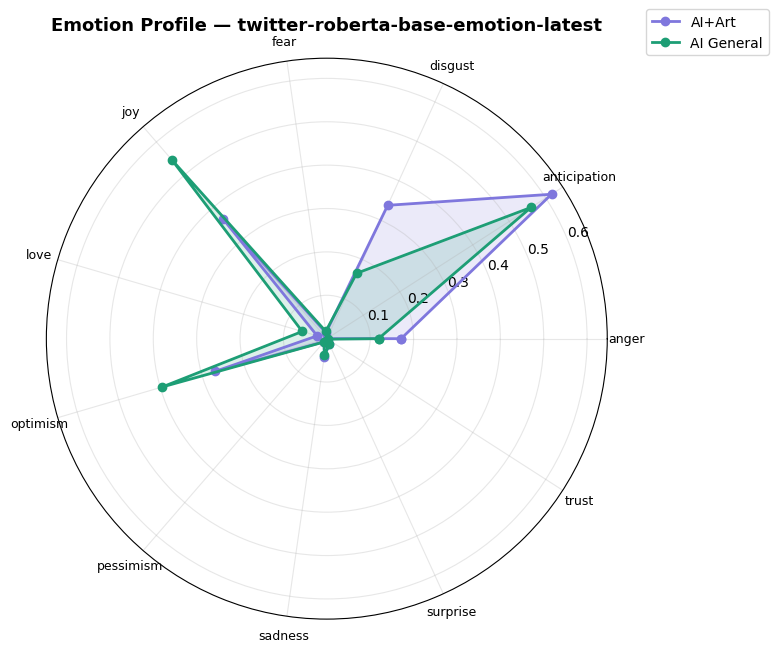

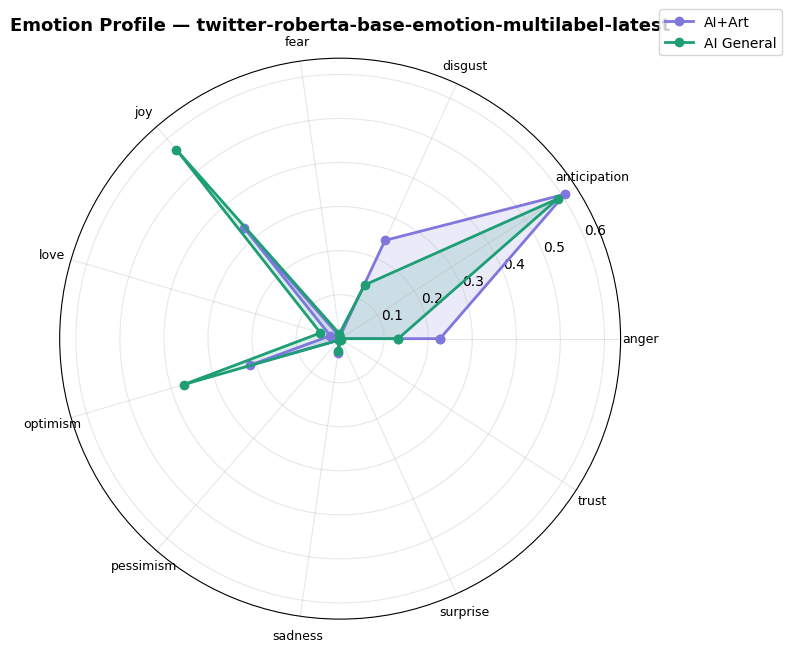

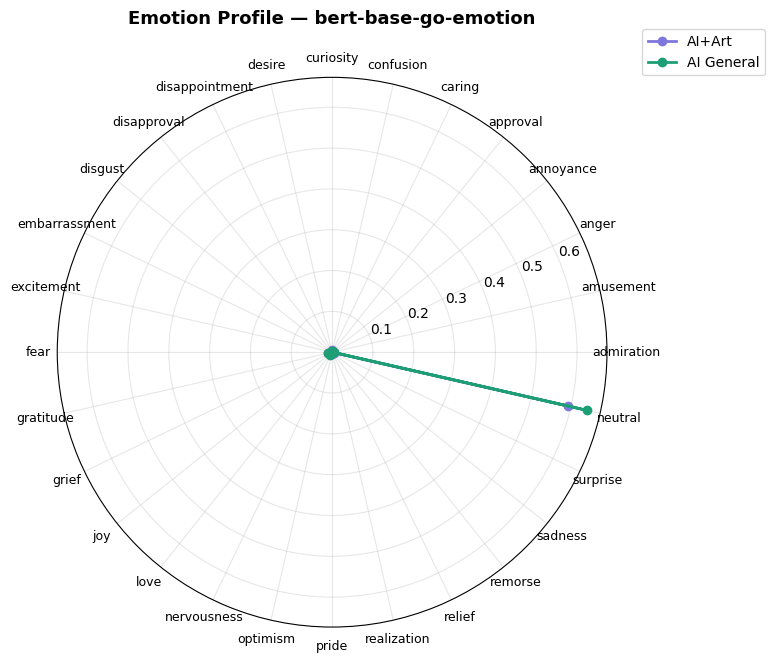

In [16]:
%%time
# ── Radar chart for multilabel emotion models ────────────────────
emotions_11 = list(MODEL_REGISTRY['cardiffnlp/twitter-roberta-base-emotion-latest']['labels'].values())

ds_colors = {'art_test': '#7F77DD', 'ai_test': '#1D9E75'}
ds_names  = {'art_test': 'AI+Art', 'ai_test': 'AI General'}

# One radar per multilabel model
MULTILABEL_MODELS = [m for m in MODELS_TO_RUN
                     if MODEL_REGISTRY[m]['classification'] == 'multilabel'
                     and MODEL_REGISTRY[m]['task'] == 'emotion']

for model_name in MULTILABEL_MODELS:
    alias = model_name.split('/')[-1]
    model_labels = list(MODEL_REGISTRY[model_name]['labels'].values())
    
    ds_data = {}
    for ds_key in ['art_test', 'ai_test']:
        key = (alias, ds_key)
        if key not in all_results:
            continue
        r = all_results[key]
        total = r['total'] or 1
        ds_data[ds_key] = [r['counts'].get(e, 0) / total for e in model_labels]
    
    if len(ds_data) < 1:
        continue
    
    angles = np.linspace(0, 2 * np.pi, len(model_labels), endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for ds_key, proportions in ds_data.items():
        values = proportions + proportions[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=ds_names[ds_key], color=ds_colors[ds_key])
        ax.fill(angles, values, alpha=0.15, color=ds_colors[ds_key])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(model_labels, fontsize=9)
    ax.set_title(f'Emotion Profile — {alias}', fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'emotion_radar_{alias}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7d. Cross-model agreement (all sentiment model pairs)

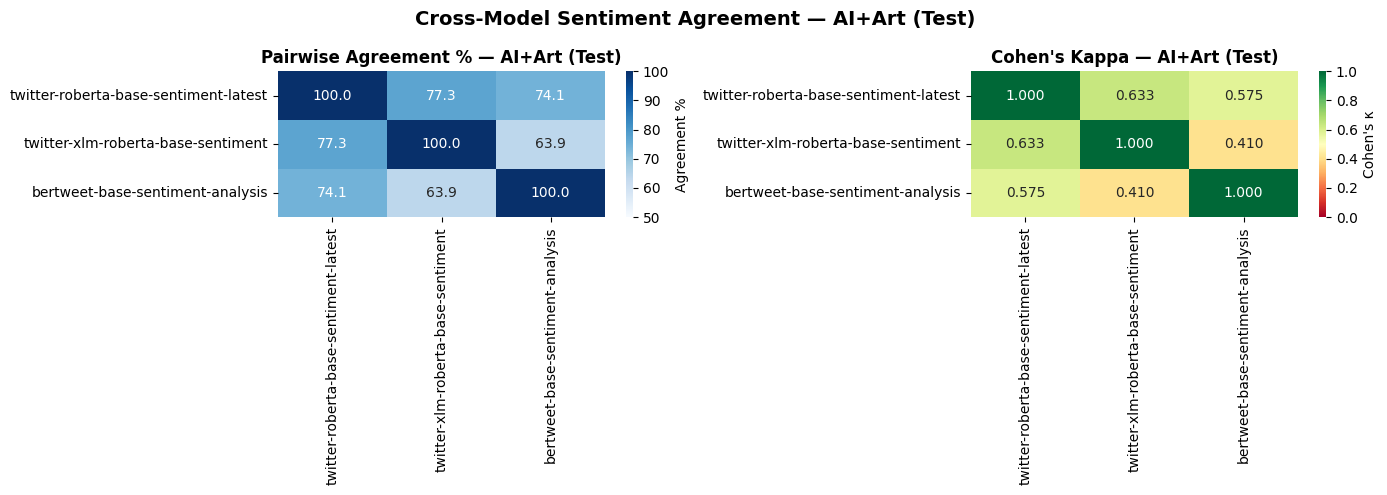

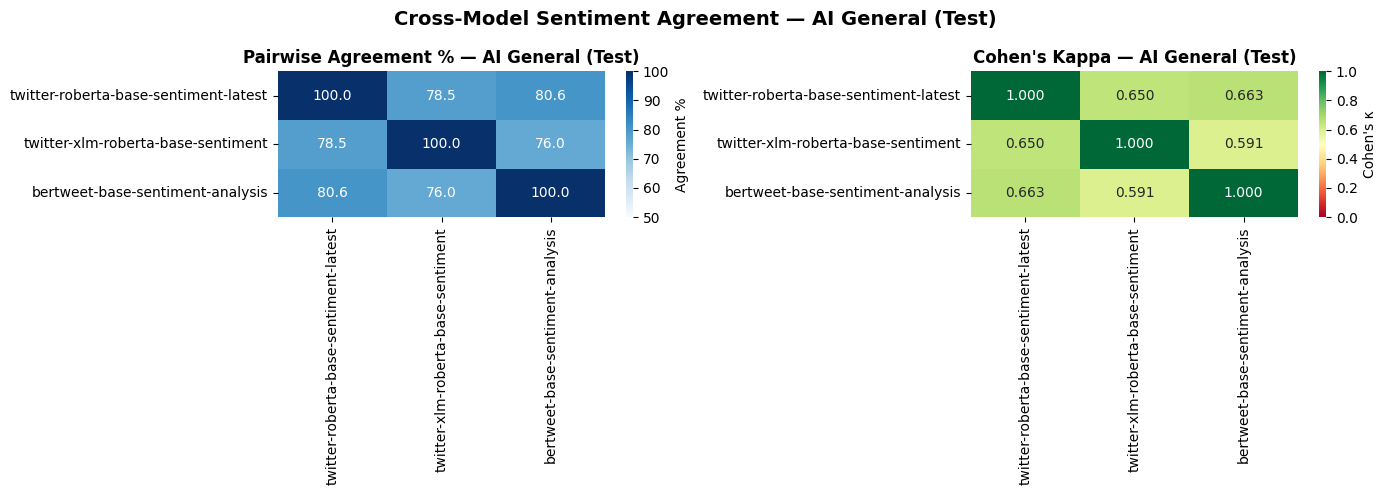

In [17]:
%%time
# ── N×N agreement for all sentiment models ───────────────────────
from sklearn.metrics import cohen_kappa_score as kappa_score
from itertools import combinations

for ds_key in ['art_test', 'ai_test']:
    ds_label = DATASETS[ds_key]['label']
    
    # Collect normalized labels per model
    model_labels_map = {}
    for model_name in SENTIMENT_MODELS:
        alias = model_name.split('/')[-1]
        key = (alias, ds_key)
        if key not in all_results:
            continue
        r = all_results[key]
        labels = [SENTIMENT_NORMALIZE.get(tw['label'], tw['label']) for tw in r['tweets']]
        model_labels_map[alias] = labels
    
    aliases = list(model_labels_map.keys())
    n = len(aliases)
    if n < 2:
        continue
    
    # Build agreement + kappa matrices
    agree_matrix = np.zeros((n, n))
    kappa_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                agree_matrix[i, j] = 100.0
                kappa_matrix[i, j] = 1.0
            else:
                la, lb = model_labels_map[aliases[i]], model_labels_map[aliases[j]]
                if len(la) != len(lb):
                    continue
                agree = sum(a == b for a, b in zip(la, lb)) / len(la) * 100
                agree_matrix[i, j] = agree
                try:
                    kappa_matrix[i, j] = kappa_score(la, lb)
                except:
                    kappa_matrix[i, j] = 0
    
    # Plot agreement %
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(agree_matrix, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=aliases, yticklabels=aliases, ax=axes[0],
                vmin=50, vmax=100, cbar_kws={'label': 'Agreement %'})
    axes[0].set_title(f'Pairwise Agreement % — {ds_label}', fontweight='bold')
    
    sns.heatmap(kappa_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=aliases, yticklabels=aliases, ax=axes[1],
                vmin=0, vmax=1, cbar_kws={'label': "Cohen's κ"})
    axes[1].set_title(f"Cohen's Kappa — {ds_label}", fontweight='bold')
    
    plt.suptitle(f'Cross-Model Sentiment Agreement — {ds_label}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'cross_model_agreement_{ds_key}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7e. Model summary table

In [18]:
%%time
# ── Summary table: all models × all test datasets ────────────────
rows = []
for model_name in MODELS_TO_RUN:
    alias = model_name.split('/')[-1]
    config = MODEL_REGISTRY[model_name]
    for ds_key in TEST_SETS:
        key = (alias, ds_key)
        if key not in all_results:
            continue
        r = all_results[key]
        
        # Mean confidence (single-label models only)
        if config['classification'] == 'single':
            mean_conf = np.mean([tw['confidence'] for tw in r['tweets']]) if r['tweets'] else 0
            top_label = r['counts'].most_common(1)[0][0] if r['counts'] else '—'
            top_pct = r['counts'].most_common(1)[0][1] / r['total'] * 100 if r['total'] else 0
        else:
            mean_conf = np.mean([max(tw['scores'].values()) for tw in r['tweets']]) if r['tweets'] else 0
            top_label = r['counts'].most_common(1)[0][0] if r['counts'] else '—'
            top_pct = r['counts'].most_common(1)[0][1] / r['total'] * 100 if r['total'] else 0
        
        rows.append({
            'Model': alias,
            'Task': config['task'],
            'Type': config['classification'],
            'Labels': len(config['labels']),
            'Dataset': DATASETS[ds_key]['label'],
            'Tweets': r['total'],
            'Top Label': top_label,
            'Top %': f"{top_pct:.1f}%",
            'Mean Conf': f"{mean_conf:.3f}",
        })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
df_summary.to_csv(sentiment_folder / 'model_summary_test.csv', index=False)
print(f"\nSaved to {sentiment_folder / 'model_summary_test.csv'}")

                                         Model      Task       Type  Labels           Dataset  Tweets    Top Label Top % Mean Conf
         twitter-roberta-base-sentiment-latest sentiment     single       3 AI General (Test)     881      neutral 51.3%     0.778
         twitter-roberta-base-sentiment-latest sentiment     single       3     AI+Art (Test)     216      neutral 43.5%     0.749
            twitter-xlm-roberta-base-sentiment sentiment     single       3 AI General (Test)     881      Neutral 51.2%     0.661
            twitter-xlm-roberta-base-sentiment sentiment     single       3     AI+Art (Test)     216     Negative 44.0%     0.633
           twitter-roberta-base-emotion-latest   emotion multilabel      11 AI General (Test)     881 anticipation 56.0%     0.818
           twitter-roberta-base-emotion-latest   emotion multilabel      11     AI+Art (Test)     216 anticipation 61.6%     0.783
twitter-roberta-base-emotion-multilabel-latest   emotion multilabel      11 AI Gene

# 8. Full Dataset Runs (Queue for GPU Session)

**DO NOT run this section on CPU** — it will take 15+ hours.
Request a GPU node (`gpu-interactive` or `gpu` partition) first.

Each model runs on the full AI-general dataset in 10 blocks with checkpointing.
The Art subset is small enough to run in a single pass.

**Estimated GPU time:** ~30-60 min per model.

In [19]:
%%time
assert torch.cuda.is_available(), "GPU required for Section 8. Launch a GPU session first."
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: Tesla T4


In [20]:
%%time
# ── RUN ON GPU ONLY ──────────────────────────────────────────────
FULL_MODELS = [
    'cardiffnlp/twitter-roberta-base-sentiment-latest',
    'cardiffnlp/twitter-roberta-base-emotion-multilabel-latest',
]

FULL_SETS = ['art_full']  # running on art first - ai_full after

def classify_full_blocked(input_path, output_path, model_name, model_config,
                          hf_model, tokenizer, device, batch_size, threshold,
                          num_blocks=10):
    """Block-based classification with checkpointing. Resumes from last complete block."""
    block_dir = block_folder / model_name.split('/')[-1]
    block_dir.mkdir(parents=True, exist_ok=True)
    
    with open(input_path, 'r') as f:
        total = sum(1 for _ in f)
    print(f"  Total: {total:,} tweets, {num_blocks} blocks")
    
    block_size = total // num_blocks
    
    for bid in range(num_blocks):
        bp = block_dir / f'block_{bid}.json'
        expected = block_size if bid < num_blocks - 1 else total - block_size * (num_blocks - 1)
        
        if bp.exists():
            with open(bp, 'r') as f:
                if sum(1 for _ in f) >= int(expected * 0.95):
                    print(f"  Block {bid} done. Skipping.")
                    continue
        
        print(f"  Block {bid+1}/{num_blocks}...")
        start = bid * block_size
        buffer, meta = [], []
        
        with open(input_path, 'r', encoding='utf-8') as infile, \
             open(bp, 'w', encoding='utf-8') as outfile:
            for _ in range(start):
                try: next(infile)
                except StopIteration: break
            
            for _ in tqdm(range(expected), desc=f"Block {bid}"):
                try: twit = json.loads(next(infile))
                except (StopIteration, json.JSONDecodeError): break
                
                if 'classifications' not in twit:
                    twit['classifications'] = {}
                cleaned = preprocess(twit.get('text', ''), style=model_config['preprocessing'])
                
                if cleaned.strip():
                    buffer.append(cleaned)
                    meta.append(twit)
                else:
                    twit['classifications'][model_name] = empty_result(model_config)
                    outfile.write(json.dumps(twit, ensure_ascii=False) + '\n')
                
                if len(buffer) >= batch_size:
                    for tw, res in zip(meta, run_batch(buffer, hf_model, tokenizer,
                                                       model_config, device, threshold)):
                        tw['classifications'][model_name] = res
                        outfile.write(json.dumps(tw, ensure_ascii=False) + '\n')
                    buffer.clear(); meta.clear()
            
            if buffer:
                for tw, res in zip(meta, run_batch(buffer, hf_model, tokenizer,
                                                   model_config, device, threshold)):
                    tw['classifications'][model_name] = res
                    outfile.write(json.dumps(tw, ensure_ascii=False) + '\n')
    
    # Merge
    print(f"  Merging → {output_path.name}")
    with open(output_path, 'w', encoding='utf-8') as out:
        for bid in range(num_blocks):
            bp = block_dir / f'block_{bid}.json'
            if bp.exists():
                with open(bp, 'r') as inp:
                    out.write(inp.read())

# ── Run all models on all full datasets ──────────────────────────
for model_name in FULL_MODELS:
    config = MODEL_REGISTRY[model_name]
    alias = model_name.split('/')[-1]
    
    if model_name in loaded_models:
        model, tokenizer = loaded_models[model_name]
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(model_name)
        model.to(device).eval()
        loaded_models[model_name] = (model, tokenizer)
    
    for ds_key in FULL_SETS:
        ds = DATASETS[ds_key]
        if not ds['path'].exists():
            print(f"SKIP {ds_key}: not found"); continue
        
        output = cleanedds_folder / f'{ds_key}_classified_{alias}.json'
        print(f"\n{'='*60}")
        print(f"{alias} × {ds['label']}")
        
        size_gb = ds['path'].stat().st_size / 1e9
        if size_gb < 1.0:
            classify_file(ds['path'], output, model_name, config,
                          model, tokenizer, device, BATCH_SIZE, MULTILABEL_THRESHOLD)
        else:
            classify_full_blocked(ds['path'], output, model_name, config,
                                  model, tokenizer, device, BATCH_SIZE,
                                  MULTILABEL_THRESHOLD, num_blocks=10)
        
        sanity_check(output, model_name, config, num_samples=3)

print("\n" + "=" * 60)
print("ALL FULL DATASET RUNS COMPLETE")


twitter-roberta-base-sentiment-latest × AI+Art (Full)
  Total: 3,583,101 tweets, 10 blocks
  Block 0 done. Skipping.
  Block 1 done. Skipping.
  Block 2 done. Skipping.
  Block 3 done. Skipping.
  Block 4 done. Skipping.
  Block 5 done. Skipping.
  Block 6 done. Skipping.
  Block 7 done. Skipping.
  Block 8 done. Skipping.
  Block 9 done. Skipping.
  Merging → art_full_classified_twitter-roberta-base-sentiment-latest.json

Sanity check: art_full_classified_twitter-roberta-base-sentiment-latest.json
  [Line 1] positive (0.925) | Hey 
you need perfect scores and completely AI proof content in your assignments
  [Line 2] neutral (0.736) | RT @lallamapic: La Llama is checked ✅🤣

Who wants a draw for a Checks VV edition
  [Line 3] neutral (0.898) | RT @lexfridman: Humans are an API to ChatGPT.
ChatGPT is an API to Python.
Pytho
  Done.


twitter-roberta-base-emotion-multilabel-latest × AI+Art (Full)
  Total: 3,583,101 tweets, 10 blocks
  Block 0 done. Skipping.
  Block 1 done. Skipping.
  

In [21]:
%%time
# ── 8b: AI General Full Run ──────────────────────────────────────
assert torch.cuda.is_available(), "GPU required."
print(f"GPU: {torch.cuda.get_device_name(0)}")

AI_MODELS = [
    'cardiffnlp/twitter-roberta-base-sentiment-latest',
    'cardiffnlp/twitter-roberta-base-emotion-multilabel-latest',
]

def classify_full_blocked_ai(input_path, output_path, model_name, model_config,
                              hf_model, tokenizer, device, batch_size, threshold,
                              num_blocks=50):
    """Same as classify_full_blocked but with ai_full__ prefix on block dirs."""
    block_dir = block_folder / f"ai_full__{model_name.split('/')[-1]}"
    block_dir.mkdir(parents=True, exist_ok=True)

    with open(input_path, 'r') as f:
        total = sum(1 for _ in f)
    print(f"  Total: {total:,} tweets, {num_blocks} blocks")

    block_size = total // num_blocks

    for bid in range(num_blocks):
        bp = block_dir / f'block_{bid}.json'
        expected = block_size if bid < num_blocks - 1 else total - block_size * (num_blocks - 1)

        if bp.exists():
            with open(bp, 'r') as f:
                existing = sum(1 for _ in f)
            if existing >= int(expected * 0.95):
                print(f"  Block {bid} done ({existing:,} lines). Skipping.")
                continue
            else:
                print(f"  Block {bid} incomplete ({existing:,}/{expected:,}). Re-running.")

        print(f"  Block {bid+1}/{num_blocks} ({expected:,} tweets)...")
        start = bid * block_size
        buffer, meta = [], []

        with open(input_path, 'r', encoding='utf-8') as infile, \
             open(bp, 'w', encoding='utf-8') as outfile:
            for _ in range(start):
                try: next(infile)
                except StopIteration: break

            for _ in tqdm(range(expected), desc=f"Block {bid}"):
                try: twit = json.loads(next(infile))
                except (StopIteration, json.JSONDecodeError): break

                if 'classifications' not in twit:
                    twit['classifications'] = {}
                cleaned = preprocess(twit.get('text', ''), style=model_config['preprocessing'])

                if cleaned.strip():
                    buffer.append(cleaned)
                    meta.append(twit)
                else:
                    twit['classifications'][model_name] = empty_result(model_config)
                    outfile.write(json.dumps(twit, ensure_ascii=False) + '\n')

                if len(buffer) >= batch_size:
                    for tw, res in zip(meta, run_batch(buffer, hf_model, tokenizer,
                                                       model_config, device, threshold)):
                        tw['classifications'][model_name] = res
                        outfile.write(json.dumps(tw, ensure_ascii=False) + '\n')
                    buffer.clear(); meta.clear()

            if buffer:
                for tw, res in zip(meta, run_batch(buffer, hf_model, tokenizer,
                                                   model_config, device, threshold)):
                    tw['classifications'][model_name] = res
                    outfile.write(json.dumps(tw, ensure_ascii=False) + '\n')

    # Merge
    print(f"  Merging → {output_path.name}")
    with open(output_path, 'w', encoding='utf-8') as out:
        merged = 0
        for bid in range(num_blocks):
            bp = block_dir / f'block_{bid}.json'
            if bp.exists():
                with open(bp, 'r') as inp:
                    for line in inp:
                        out.write(line)
                        merged += 1
    print(f"  Merged {merged:,} tweets.")


# ── Run ──────────────────────────────────────────────────────────
t0_ai = time.time()
for model_name in AI_MODELS:
    config = MODEL_REGISTRY[model_name]
    alias = model_name.split('/')[-1]

    if model_name in loaded_models:
        model, tokenizer = loaded_models[model_name]
    else:
        print(f"\nLoading {alias}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(model_name)
        model.to(device).eval()
        loaded_models[model_name] = (model, tokenizer)

    ds = DATASETS['ai_full']
    if not ds['path'].exists():
        print(f"SKIP ai_full: not found"); continue

    output = cleanedds_folder / f'ai_full_classified_{alias}.json'
    print(f"\n{'='*60}")
    print(f"{alias} × {ds['label']}")

    classify_full_blocked_ai(ds['path'], output, model_name, config,
                              model, tokenizer, device, BATCH_SIZE,
                              MULTILABEL_THRESHOLD, num_blocks=10)

    if output.exists():
        sanity_check(output, model_name, config, num_samples=3)

print(f"\nAI GENERAL FULL RUNS — {(time.time()-t0_ai)/60:.1f} min")

GPU: Tesla T4

twitter-roberta-base-sentiment-latest × AI General (Full)
  Total: 17,410,035 tweets, 10 blocks
  Block 0 done (1,741,003 lines). Skipping.
  Block 1 done (1,741,003 lines). Skipping.
  Block 2 done (1,741,003 lines). Skipping.
  Block 3 done (1,741,003 lines). Skipping.
  Block 4 done (1,741,003 lines). Skipping.
  Block 5 done (1,741,003 lines). Skipping.
  Block 6 done (1,741,003 lines). Skipping.
  Block 7 done (1,741,003 lines). Skipping.
  Block 8 done (1,741,003 lines). Skipping.
  Block 9 done (1,741,008 lines). Skipping.
  Merging → ai_full_classified_twitter-roberta-base-sentiment-latest.json
  Merged 17,410,035 tweets.

Sanity check: ai_full_classified_twitter-roberta-base-sentiment-latest.json
  [Line 1] positive (0.925) | Hey 
you need perfect scores and completely AI proof content in your assignments
  [Line 2] neutral (0.736) | RT @lallamapic: La Llama is checked ✅🤣

Who wants a draw for a Checks VV edition
  [Line 3] neutral (0.898) | RT @lexfridman: Huma

Block 9:   0%|          | 0/1741008 [00:00<?, ?it/s]/tmp/ipykernel_1341470/753667056.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=not is_deberta):
Block 9: 100%|██████████| 1741008/1741008 [39:43<00:00, 730.48it/s]


  Merging → ai_full_classified_twitter-roberta-base-emotion-multilabel-latest.json
  Merged 17,401,060 tweets.

Sanity check: ai_full_classified_twitter-roberta-base-emotion-multilabel-latest.json
  [Line 1] ['anticipation', 'joy', 'optimism'] | top-3: {'anticipation': 0.85693359375, 'optimism': 0.8212890625, 'joy': 0.767578125}
  [Line 2] ['anticipation', 'joy'] | top-3: {'anticipation': 0.7412109375, 'joy': 0.55224609375, 'optimism': 0.1837158203125}
  [Line 3] ['joy'] | top-3: {'joy': 0.55859375, 'anticipation': 0.45458984375, 'optimism': 0.3359375}
  Done.


AI GENERAL FULL RUNS — 56.7 min


In [22]:
%%time
# ── 9. Load Full Dataset Results ─────────────────────────────────
full_results = {}

FULL_RESULT_MODELS = [
    'cardiffnlp/twitter-roberta-base-sentiment-latest',
    'cardiffnlp/twitter-roberta-base-emotion-multilabel-latest',
]

for model_name in FULL_RESULT_MODELS:
    config = MODEL_REGISTRY[model_name]
    alias = model_name.split('/')[-1]

    for ds_key in ['art_full', 'ai_full']:
        output = cleanedds_folder / f'{ds_key}_classified_{alias}.json'
        if not output.exists():
            print(f"  SKIP {ds_key} × {alias}: not found")
            continue

        counts, tweets, labels = load_results(output, model_name, config)
        full_results[(alias, ds_key)] = {
            'counts': counts, 'tweets': tweets, 'labels': labels,
            'total': len(tweets), 'config': config, 'model_name': model_name,
        }
        print(f"  Loaded {ds_key} × {alias}: {len(tweets):,} tweets")

print(f"\nLoaded {len(full_results)} full-dataset result sets")

  Loaded art_full × twitter-roberta-base-sentiment-latest: 4,057,340 tweets
  Loaded ai_full × twitter-roberta-base-sentiment-latest: 17,410,035 tweets
  Loaded art_full × twitter-roberta-base-emotion-multilabel-latest: 3,583,101 tweets
  Loaded ai_full × twitter-roberta-base-emotion-multilabel-latest: 17,401,060 tweets

Loaded 4 full-dataset result sets


# 9. Summary

In [23]:
%%time
print("=" * 60)
print("SENTIMENT / EMOTION ANALYSIS — SESSION SUMMARY")
print("=" * 60)
print(f"  Device:   {device}")
print(f"  Models:   {len(MODELS_TO_RUN)}")
print(f"  Datasets: {len(DATASETS)}")
print(f"  Runs:     {len(run_results)}")
print()
for (model_name, ds_key), path in run_results.items():
    alias = model_name.split('/')[-1]
    exists = path.exists()
    print(f"  {ds_key:10} × {alias:45} → {path.name} ({'OK' if exists else 'MISSING'})")


SENTIMENT / EMOTION ANALYSIS — SESSION SUMMARY
  Device:   cuda
  Models:   10
  Datasets: 4
  Runs:     20

  ai_test    × twitter-roberta-base-sentiment-latest         → ai_test_classified_twitter-roberta-base-sentiment-latest.json (OK)
  art_test   × twitter-roberta-base-sentiment-latest         → art_test_classified_twitter-roberta-base-sentiment-latest.json (OK)
  ai_test    × twitter-xlm-roberta-base-sentiment            → ai_test_classified_twitter-xlm-roberta-base-sentiment.json (OK)
  art_test   × twitter-xlm-roberta-base-sentiment            → art_test_classified_twitter-xlm-roberta-base-sentiment.json (OK)
  ai_test    × twitter-roberta-base-emotion-latest           → ai_test_classified_twitter-roberta-base-emotion-latest.json (OK)
  art_test   × twitter-roberta-base-emotion-latest           → art_test_classified_twitter-roberta-base-emotion-latest.json (OK)
  ai_test    × twitter-roberta-base-emotion-multilabel-latest → ai_test_classified_twitter-roberta-base-emotion-multil

In [24]:
%%time
# ── 9a. Full Dataset Label Distributions ─────────────────────────
print("=" * 70)
print("FULL DATASET — LABEL DISTRIBUTIONS")
print("=" * 70)

for (alias, ds_key), r in sorted(full_results.items()):
    ds_label = DATASETS[ds_key]['label']
    total = r['total']
    config = r['config']

    print(f"\n  {alias} × {ds_label} (n={total:,}):")

    if config['classification'] == 'single':
        for lbl in r['labels']:
            cnt = r['counts'].get(lbl, 0)
            pct = cnt / max(total, 1) * 100
            print(f"    {lbl:15s}: {cnt:>8,}  ({pct:5.1f}%)")
    else:
        for lbl in r['labels']:
            cnt = r['counts'].get(lbl, 0)
            pct = cnt / max(total, 1) * 100
            print(f"    {lbl:15s}: {cnt:>8,}  ({pct:5.1f}% of tweets)")

FULL DATASET — LABEL DISTRIBUTIONS

  twitter-roberta-base-emotion-multilabel-latest × AI General (Full) (n=17,401,060):
    anger          : 3,133,078  ( 18.0% of tweets)
    anticipation   : 9,145,510  ( 52.6% of tweets)
    disgust        : 3,327,924  ( 19.1% of tweets)
    fear           :  591,428  (  3.4% of tweets)
    joy            : 8,272,652  ( 47.5% of tweets)
    love           :  513,089  (  2.9% of tweets)
    optimism       : 6,276,605  ( 36.1% of tweets)
    pessimism      :   66,305  (  0.4% of tweets)
    sadness        :  792,973  (  4.6% of tweets)
    surprise       :  235,114  (  1.4% of tweets)
    trust          :    5,740  (  0.0% of tweets)

  twitter-roberta-base-emotion-multilabel-latest × AI+Art (Full) (n=3,583,101):
    anger          : 1,030,111  ( 28.7% of tweets)
    anticipation   : 1,609,426  ( 44.9% of tweets)
    disgust        : 1,088,980  ( 30.4% of tweets)
    fear           :   82,373  (  2.3% of tweets)
    joy            : 1,610,605  ( 45.0% 

In [25]:
%%time
# ── 9b. Example Tweets per Category ─────────────────────────────
EXAMPLES_PER_CLASS = 5

for (alias, ds_key), r in sorted(full_results.items()):
    ds_label = DATASETS[ds_key]['label']
    config = r['config']

    print(f"\n{'='*70}")
    print(f"  {alias} × {ds_label}")
    print(f"{'='*70}")

    if config['classification'] == 'single':
        for lbl in r['labels']:
            matching = [(tw['text'][:140], tw['confidence'])
                        for tw in r['tweets'] if tw.get('label') == lbl]
            matching.sort(key=lambda x: -x[1])
            print(f"\n  {lbl} ({len(matching):,} tweets):")
            for text, conf in matching[:EXAMPLES_PER_CLASS]:
                print(f"    [{conf:.3f}] {text}")
    else:
        for lbl in r['labels']:
            matching = [(tw['text'][:140], tw['scores'].get(lbl, 0))
                        for tw in r['tweets'] if lbl in tw.get('labels', [])]
            matching.sort(key=lambda x: -x[1])
            print(f"\n  {lbl} ({len(matching):,} tweets):")
            for text, score in matching[:EXAMPLES_PER_CLASS]:
                print(f"    [{score:.3f}] {text}")


  twitter-roberta-base-emotion-multilabel-latest × AI General (Full)

  anger (3,133,078 tweets):
    [0.991] @sama PROGRAMING BIAS behavior is the worst mistake someone can DELIBERATELY PLAN

There is nothing more despicable than imposing your view 
    [0.991] Look at the Embarrassing AI creation from Qatar trying to pretend the knee was OFFSIDE 😂😂 this country is a disgrace and cheats, Let this be
    [0.990] @vladquant Honestly, with the disgusting abuse I've seen 13-year-olds on Reddit throwing to ChatGPT, I'm not really that surprised that peop
    [0.990] @Y_I_K_ES That's a good point, and it's something else my AI avoids -- point being not to promote, but to demonstrate that AI is not the ene
    [0.990] @Nucksen_DD @The_Row_House @USClaireForce It's amazing how u guys can pull tne victim card and victimize yourselves after getting called out

  anticipation (9,145,510 tweets):
    [0.938] @zachsilberberg I have a burning desire to know how to make content with this AI
    [0.

# VISUALS

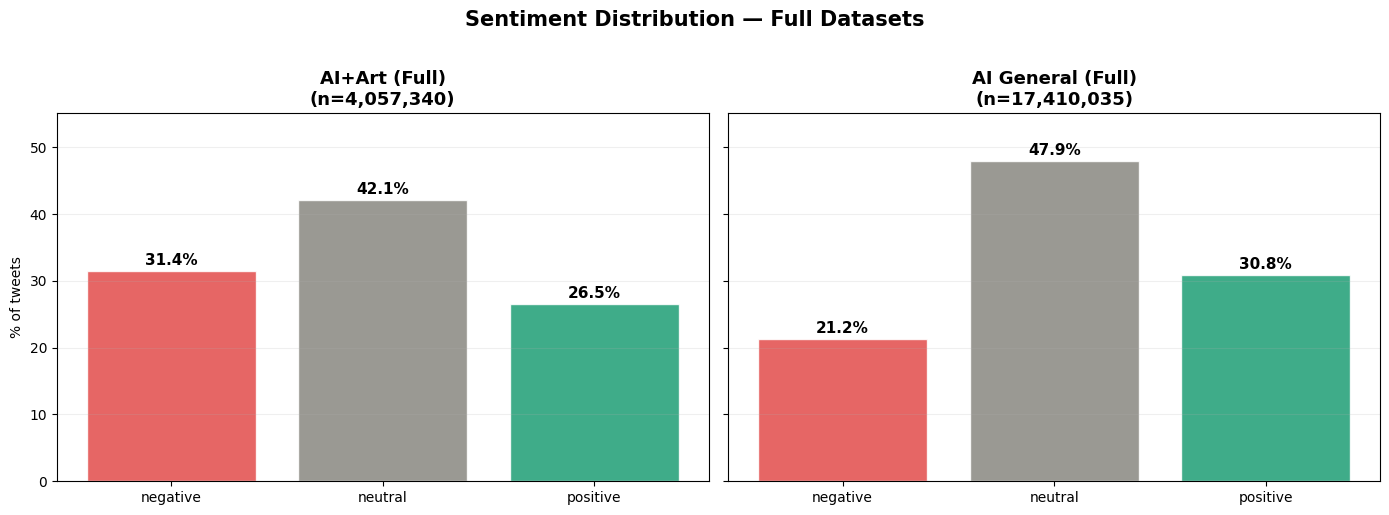

In [26]:
%%time
# ── 10a. Sentiment Distribution — Art vs General ─────────────────
SENTIMENT_NORMALIZE = {
    'negative': 'negative', 'Negative': 'negative', 'NEG': 'negative',
    'neutral': 'neutral', 'Neutral': 'neutral', 'NEU': 'neutral',
    'positive': 'positive', 'Positive': 'positive', 'POS': 'positive',
}
SENTIMENT_ORDER = ['negative', 'neutral', 'positive']
SENTIMENT_COLORS = {'negative': '#E24B4A', 'neutral': '#888780', 'positive': '#1D9E75'}

sent_alias = 'twitter-roberta-base-sentiment-latest'
available_ds = [k for k in ['art_full', 'ai_full'] if (sent_alias, k) in full_results]

fig, axes = plt.subplots(1, len(available_ds), figsize=(7 * len(available_ds), 5), sharey=True)
if len(available_ds) == 1:
    axes = [axes]

for i, ds_key in enumerate(available_ds):
    r = full_results[(sent_alias, ds_key)]
    total = r['total']
    ds_label = DATASETS[ds_key]['label']

    normalized = Counter()
    for lbl, cnt in r['counts'].items():
        normalized[SENTIMENT_NORMALIZE.get(lbl, lbl)] += cnt

    props = [normalized.get(lbl, 0) / max(total, 1) * 100 for lbl in SENTIMENT_ORDER]
    colors = [SENTIMENT_COLORS[lbl] for lbl in SENTIMENT_ORDER]

    bars = axes[i].bar(SENTIMENT_ORDER, props, color=colors, alpha=0.85, edgecolor='white')
    for bar, pct in zip(bars, props):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    axes[i].set_title(f'{ds_label}\n(n={total:,})', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('% of tweets' if i == 0 else '')
    axes[i].set_ylim(0, max(props) * 1.15)
    axes[i].grid(axis='y', alpha=0.2)

plt.suptitle('Sentiment Distribution — Full Datasets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'full_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

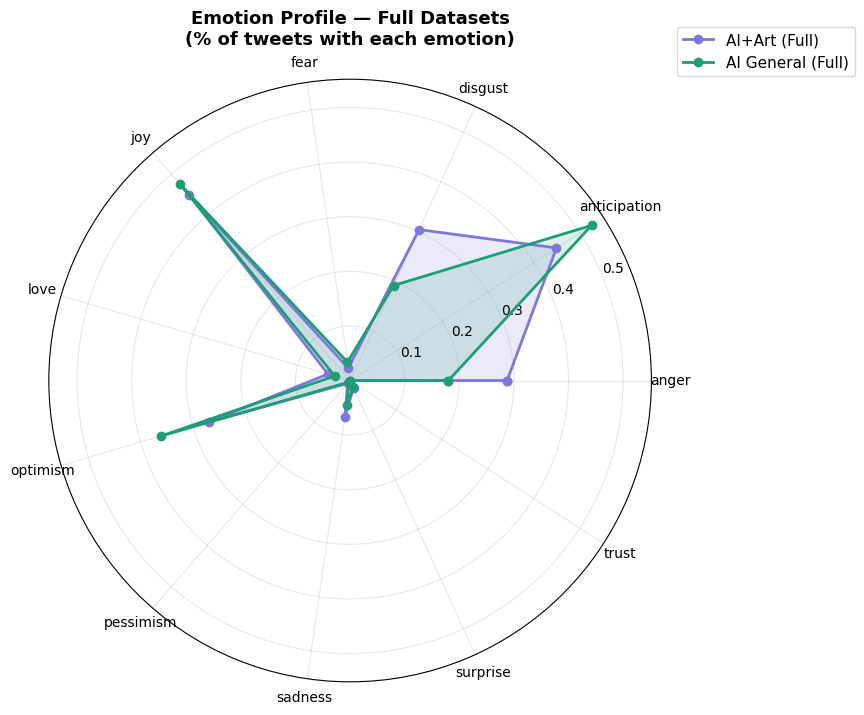

In [27]:
%%time
# ── 10b. Emotion Radar — Art vs General ──────────────────────────
emotion_alias = 'twitter-roberta-base-emotion-multilabel-latest'
emotion_labels = list(MODEL_REGISTRY['cardiffnlp/twitter-roberta-base-emotion-multilabel-latest']['labels'].values())

ds_colors = {'art_full': '#7F77DD', 'ai_full': '#1D9E75'}
ds_names  = {'art_full': 'AI+Art (Full)', 'ai_full': 'AI General (Full)'}

ds_data = {}
for ds_key in ['art_full', 'ai_full']:
    key = (emotion_alias, ds_key)
    if key not in full_results:
        continue
    r = full_results[key]
    total = r['total'] or 1
    ds_data[ds_key] = [r['counts'].get(e, 0) / total for e in emotion_labels]

if ds_data:
    angles = np.linspace(0, 2 * np.pi, len(emotion_labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    for ds_key, proportions in ds_data.items():
        values = proportions + proportions[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=ds_names.get(ds_key, ds_key),
                color=ds_colors.get(ds_key, '#888'))
        ax.fill(angles, values, alpha=0.15, color=ds_colors.get(ds_key, '#888'))

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(emotion_labels, fontsize=10)
    ax.set_title('Emotion Profile — Full Datasets\n(% of tweets with each emotion)',
                 fontsize=13, fontweight='bold', pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'full_emotion_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

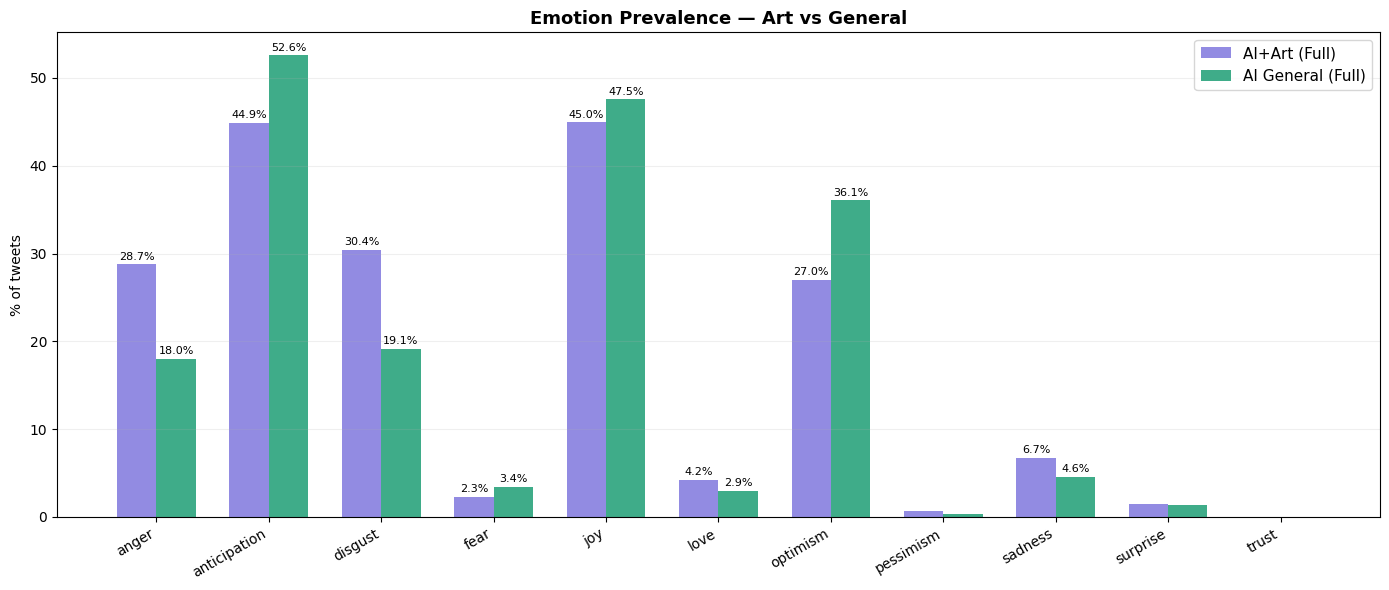

In [28]:
%%time
# ── 10c. Emotion Prevalence — Grouped Bars ───────────────────────
if ds_data:
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(emotion_labels))
    width = 0.35

    for i, (ds_key, proportions) in enumerate(ds_data.items()):
        pcts = [p * 100 for p in proportions]
        bars = ax.bar(x + i * width, pcts, width,
                      label=ds_names.get(ds_key, ds_key),
                      color=ds_colors.get(ds_key, '#888'), alpha=0.85)
        for bar, pct in zip(bars, pcts):
            if pct > 2:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(emotion_labels, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('% of tweets')
    ax.set_title('Emotion Prevalence — Art vs General', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'full_emotion_comparison_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

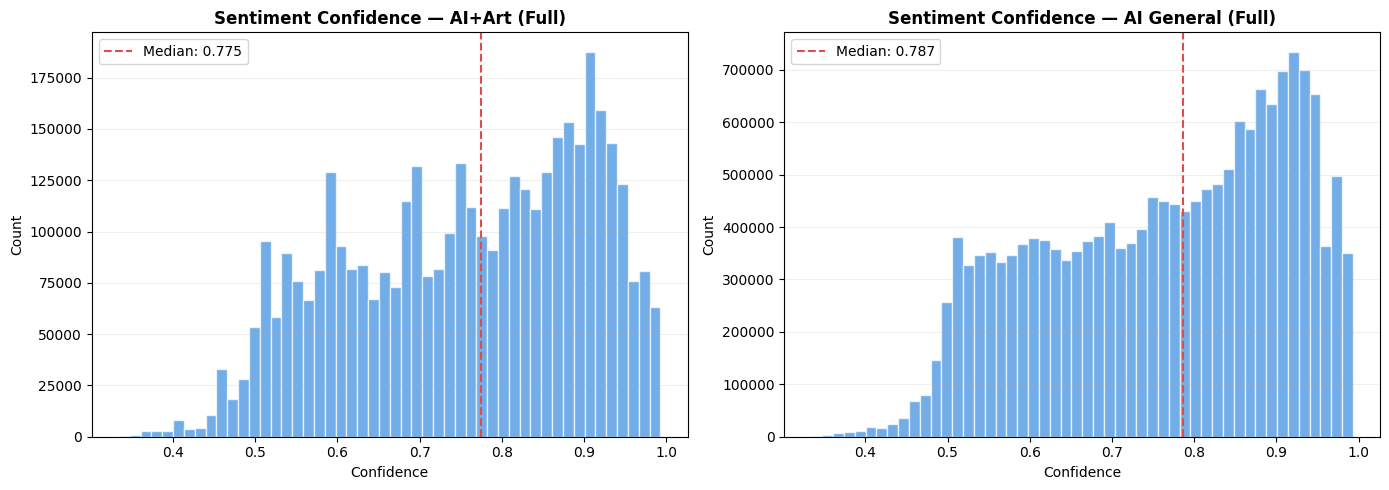

In [29]:
%%time
# ── 10d. Confidence Distribution ─────────────────────────────────
available_sent = [(sent_alias, k) for k in ['art_full', 'ai_full'] if (sent_alias, k) in full_results]

if available_sent:
    fig, axes = plt.subplots(1, len(available_sent), figsize=(7 * len(available_sent), 5))
    if len(available_sent) == 1:
        axes = [axes]

    for i, (alias, ds_key) in enumerate(available_sent):
        r = full_results[(alias, ds_key)]
        ds_label = DATASETS[ds_key]['label']
        confidences = [tw['confidence'] for tw in r['tweets'] if 'confidence' in tw]

        if confidences:
            axes[i].hist(confidences, bins=50, alpha=0.7, color='#378ADD', edgecolor='white')
            axes[i].axvline(np.median(confidences), color='#E24B4A', linestyle='--',
                            label=f'Median: {np.median(confidences):.3f}')
            axes[i].set_title(f'Sentiment Confidence — {ds_label}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Confidence')
            axes[i].set_ylabel('Count')
            axes[i].legend()
            axes[i].grid(axis='y', alpha=0.2)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'full_confidence_histograms.png', dpi=150, bbox_inches='tight')
    plt.show()

In [30]:
%%time
# ── 10e. Summary Table ───────────────────────────────────────────
summary_rows = []
for (alias, ds_key), r in sorted(full_results.items()):
    config = r['config']
    ds_label = DATASETS[ds_key]['label']

    top_label = max(r['counts'], key=r['counts'].get) if r['counts'] else '—'
    top_pct = r['counts'].get(top_label, 0) / max(r['total'], 1) * 100

    if config['classification'] == 'single':
        confs = [tw.get('confidence', 0) for tw in r['tweets']]
        mean_conf = f"{np.mean(confs):.3f}" if confs else '—'
    else:
        mean_conf = '—'

    summary_rows.append({
        'Model': alias, 'Task': config['task'],
        'Dataset': ds_label, 'Tweets': f"{r['total']:,}",
        'Top Label': top_label, 'Top %': f"{top_pct:.1f}%",
        'Mean Conf': mean_conf,
    })

print(pd.DataFrame(summary_rows).to_string(index=False))

                                         Model      Task           Dataset     Tweets    Top Label Top % Mean Conf
twitter-roberta-base-emotion-multilabel-latest   emotion AI General (Full) 17,401,060 anticipation 52.6%         —
twitter-roberta-base-emotion-multilabel-latest   emotion     AI+Art (Full)  3,583,101          joy 45.0%         —
         twitter-roberta-base-sentiment-latest sentiment AI General (Full) 17,410,035      neutral 47.9%     0.764
         twitter-roberta-base-sentiment-latest sentiment     AI+Art (Full)  4,057,340      neutral 42.1%     0.757


In [ ]:
# Disconnect from Colab runtime (no-op locally)
try:
    from google.colab import runtime
    runtime.unassign()
except ImportError:
    pass
